<a href="https://colab.research.google.com/github/Grinnday/FitSNAP/blob/master/DKL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -r /content/drive/MyDrive/shared_/requirements.txt #version control

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.6/310.6 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)

In [15]:
!pip install git+https://github.com/Grinnday/atomai.git

  Cloning https://github.com/Grinnday/atomai.git to /tmp/pip-req-build-os11qfz9
  Running command git clone --filter=blob:none --quiet https://github.com/Grinnday/atomai.git /tmp/pip-req-build-os11qfz9
  Resolved https://github.com/Grinnday/atomai.git to commit c4a7c2a07dc413959633f73eca7224dcb587cbea
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 9.0 MB/s eta 0:00:00
  Created wheel for atomai: filename=atomai-0.7.8-py3-none-any.whl size=162923 sha256=c6bf786faaf7af26f1dc13ad4bbb3f132d17c0a46acdf905184d508700c02da5
  Stored in directory: /tmp/pip-ephem-wheel-cache-w5tncatn/wheels/13/0f/0d/76cdf13632b4cd37bf1428827bb98a734686fe403773006507
Successfully built atomai
  Attempting uninstall: gpytorch
    Found existing installation: gpytorch 1.6.0
    Uninstalling gpytorch-1.6.0:
      Successfully uninstalled gpytorch-1.6.0


In [1]:
# -*- coding: utf-8 -*-
"""0817 advs4650-sup-0001-suppmat.ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/11v6Xa5Wy11UGdb1Ed_1yIUvz4pFdrpjk

# DKL-GPR-BO for active learning
This notebook demonstrates how to use a deep kernel learning (DKL)-based Gaussian process regression (GPR) with vector output for autonomous experiments. Here we will be using the pre-acquired experimental dataset on plasmonic nanoparticles (HAADF + EELS) from `Kevin M. Roccapriore`.

*Prepared by `Maxim Ziatdinov` (June 2021)*

* Project conceived and overseen by `Sergei Kalinin` (<font color = 'crimson'>ORNL</font>)
* Electron microscopy, data preparation, and autonomous experiment carried out by `Kevin M. Roccapriore` (<font color = 'crimson'>ORNL</font>)
* DKL codes prepared and compiled by `Maxim Ziatdinov` (<font color = 'crimson'>ORNL</font>)


We graciously thank our friends and collaborators for providing the excellent samples used in this work:
* Plasmonic nanoparticles were chemically synthesized by `Shin-Hum Cho` (<font color = 'crimson'>Samsung Electronics</font>) & `Delia J. Milliron` (<font color = 'crimson'>UT Austin</font>)
* MnPS3 crystals were grown by `Nan Huang` & `David G. Mandrus` (<font color = 'crimson'>UT Knoxville</font>)

## Installations/Imports/Downloads

#Check the GPU type/status:"""

#@title Library imports
import numpy as np
import matplotlib.pyplot as plt
import glob
import json
import scipy
from scipy import ndimage, signal, interpolate
import operator
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import pandas as pd

import matplotlib as mpl
import torch
import sys
sys.path.append('/content/atomai')
import atomai as aoi
from sklearn.model_selection import train_test_split
import gpytorch

from copy import deepcopy
from numpy.random import RandomState

from skimage import draw
from skimage.transform import resize
from skimage import color
from skimage.draw import circle_perimeter


# from IPython.display import Video
from IPython.core.display import Video
import imageio

# To stop warning logs during movie creation
import imageio.core.util

#@title Acquisition function definitions
from typing import Union
import os

def EI(model: aoi.models.dklGPR, X: Union[np.ndarray, torch.Tensor],
       best_f: Union[float, torch.Tensor], xi: Union[float, torch.Tensor] = 0.01
       ) -> np.ndarray:
    """
    Expected Improvement
    """
    tt = torch.tensor
    tor = lambda a: tt(a) if isinstance(a, (np.ndarray, float)) else a
    device=model.device
    dtype = model.dtype
    X, best_f, xi = tor(X), tor(best_f), tor(xi)
    posterior = model._compute_posterior(X.to(dtype).to(device))
    mean, sigma = posterior.mean, posterior.variance.sqrt()
    u = (mean - best_f.expand_as(mean) - xi.expand_as(mean)) / sigma
    normal = torch.distributions.Normal(torch.zeros_like(u), torch.ones_like(u))
    ucdf = normal.cdf(u)
    updf = torch.exp(normal.log_prob(u))
    obj = sigma * (updf + u * ucdf)
    return obj.detach().cpu().numpy()


def UCB(model: aoi.models.dklGPR, X: Union[np.ndarray, torch.Tensor],
        beta: Union[float, torch.Tensor] = 0.2) -> np.ndarray:
    """
    Upper confidence bound
    """
    tt = torch.tensor
    tor = lambda a: tt(a) if isinstance(a, (np.ndarray, float)) else a
    device = model.device
    dtype = model.dtype
    X, beta = tor(X), tor(beta)
    posterior = model._compute_posterior(X.to(dtype).to(device))
    mean, var = posterior.mean, posterior.variance
    delta = (beta.expand_as(mean).to(dtype).to(device) * var).sqrt()
    return (mean + delta).detach().cpu().numpy()


def CE(model: aoi.models.dklGPR, X: Union[np.ndarray, torch.Tensor]) -> np.ndarray:
    """Uncertainty-based exploration"""
    device = model.device
    dtype = model.dtype
    X = torch.tensor(X) if isinstance(X, (np.ndarray, float)) else X
    posterior = model._compute_posterior(X.to(dtype).to(device))
    obj = posterior.variance
    return obj.detach().cpu().numpy()

#@title Other functions
def plot_DKL_prediction_preacquired_notactive(model_name, structural_img, spectral_img, figsize = (15,8), energy_range = [0,-1]):

  mean,var = model_name.predict(X, batch_size = len(X))
  mean, var = mean.T, var.T
  s1, s2 = structural_img.shape[0] - window_size+1, structural_img.shape[1] - window_size+1
  s3 = y.shape[0]

  dkl_prediction = np.full((s1*s2,s3), np.nan)
  dkl_uncertainty = np.full((s1*s2,s3), np.nan)
  measurement_og = np.full((s1*s2,s3), np.nan)

  for ii in range(indices[:,0].shape[0]):
    dkl_prediction[ii] = mean[ii, :]
    dkl_uncertainty[ii] = var[ii, :]
    measurement_og[ii] = y.T[ii, :]

  dkl_prediction = dkl_prediction.reshape((s1,s2,s3))
  dkl_uncertainty = dkl_uncertainty.reshape((s1,s2,s3))
  measurement_og = measurement_og.reshape((s1,s2,s3))

  plt.figure(figsize=figsize)
  gs = gridspec.GridSpec(2,2)
  ax1,ax2 = plt.subplot(gs[0,0]), plt.subplot(gs[0,1])
  ax3,ax4 = plt.subplot(gs[1,0]), plt.subplot(gs[1,1])

  k1,k2 = energy_range[0], energy_range[1]

  im1 = ax1.imshow(np.mean(dkl_prediction[:,:,k1:k2],axis = 2), origin = 'lower')
  im2 = ax2.imshow(np.mean(dkl_uncertainty[:,:,k1:k2], axis = 2), origin = 'lower')
  ax1.set_title('DKL prediction', fontsize = 15)
  ax2.set_title('DKL uncertainty', fontsize = 15)

  cbar1 = plt.colorbar(im1, ax=ax1)
  cbar1.ax.tick_params(labelsize = 15)
  cbar2 = plt.colorbar(im2, ax=ax2)
  cbar2.ax.tick_params(labelsize = 15)

  predicted_spectrum = np.mean(mean[:,k1:k2], axis = 0)
  measured_spectrum = np.mean(y.T[:,k1:k2], axis = 0)

  ax3.plot(e_reduced[k1:k2],measured_spectrum, linewidth=6, c = 'blue', label="ground truth", zorder=0)
  ax3.plot(e_reduced[k1:k2],predicted_spectrum, linewidth=4, c='crimson', label="prediction", zorder=1)

  ax4.imshow(np.mean(measurement_og[:,:,k1:k2], axis = 2), origin = 'lower')

  leg=ax3.legend(fontsize = 20)
  for line in leg.get_lines():
    line.set_linewidth(10)

  ax3.set_xlabel('Energy loss (eV)', fontsize = 15, labelpad = 15, weight = 'bold')
  ax3.set_ylabel('Intensity (a.u.)', fontsize = 15, weight = 'bold')
  ax3.tick_params(labelsize = 15, length = 8, width = 3)
  ax3.axhline(0, c='k')

  all_axes = [ax1,ax2,ax3,ax4]
  for ax in all_axes:
    for axis in ['top','bottom','left','right']:
      ax.spines[axis].set_linewidth(3)

  ax1.axis('off'), ax2.axis('off'), ax4.axis('off')

  return dkl_prediction, dkl_uncertainty, predicted_spectrum, measured_spectrum, mean, var

def Make_AF_movies_preacquired(acquisition_functions,
                               RGB = [2,1,8],
                               brightness = 0.75,
                               measured_points_in_AF = [0,0,0],
                               measured_points_in_HAADF = [1,0,0]):

  R,G,B = RGB
  # k1,k2 = 0, -1  ## Energy bands to average across

  sr1, sr2 = structural_img.shape[0] - window_size+1, structural_img.shape[1] - window_size+1

  AF_all_color = np.zeros((len(acquisition_functions), sr1,sr2, 3))
  AF_all = np.zeros((len(acquisition_functions), sr1,sr2))
  AF_combined_all = []
  for frame in range(len(acquisition_functions)):
    # Generate IMAGE from points

    AF_frame = np.full((sr1,sr2), np.nan)
    AF_combined = np.concatenate((acquisition_functions[frame]['frames'], acquisition_functions[frame]['colors'].reshape(-1,1)), axis = 1)
    AF_combined_all.append(AF_combined)
    for p in AF_combined:
      c1,c2,c3 = int(p[0]-window_size/2), int(p[1]-window_size/2), p[2]
      AF_frame[c1-1:c1+1,c2-1:c2+2] = c3
    AF_frame = normalize_nan(AF_frame)
    AF_all[frame] = AF_frame

    # Make COLOR image from grayscale image <-- for movie later
    AF_frame_c = np.array([[[s*R*brightness,s*G*brightness,s*B*brightness] for s in r] for r in AF_frame])
    nan_coords = np.argwhere(np.isnan(AF_frame_c))[::3][:,:2]

    for coord in nan_coords:
      AF_frame_c[coord[0], coord[1]] = measured_points_in_AF
    AF_all_color[frame] = np.clip(AF_frame_c, 0, 1)
    AF_all = np.asarray(AF_all)
    # AF_combined_all = np.asarray(AF_combined_all)

  return AF_all, AF_all_color, AF_combined_all

def create_point_search_mov_preacquired(structural_img, ind, AF_combined, size = (50,50), point_radius = 3, point_color = [254,254,254], offset = 0):

  sr1, sr2 = structural_img.shape[0] - window_size+1, structural_img.shape[1] - window_size+1
  ir1, ir2 = structural_img.shape[0], structural_img.shape[1]
  cr1, cr2 = [int((ir1 - sr1)/2), int((ir2 - sr2)/2)]
  img_crop = structural_img[cr1:int(sr1+cr1), cr2:int(sr2+cr2)]

  size = [sr1,sr2]
  # Initialize stack
  Mov = np.zeros((len(AF_combined), sr1, sr2, 3))

  # Get coordinates for measured points (which are NaN)
  for frame in range(len(Mov)):
    temp = np.full((size), np.nan)
    for p in AF_combined[frame]:
      c1,c2,c3 = int(p[0]-window_size/2), int(p[1]-window_size/2), p[2]
      temp[c1,c2] = c3
      #print(ind[frame][0], ind[frame][1])
      temp[int(ind[frame][0]), int(ind[frame][1])] = 1
    nan_coords = np.argwhere(np.isnan(temp))[:,:2]

    # Convert to color, and draw the measured points on each frame
    img_c = color.gray2rgb(normalize(img_crop))
    for m in nan_coords:
      a,b = m[0] + offset, m[1] + offset
      rr,cc = circle_perimeter(a,b,point_radius)
      draw.set_color(img_c, (rr,cc), point_color)
    Mov[frame] = img_c

  return Mov

def normalize_nan(image):
  normed = (image - np.nanmin(image))/(np.nanmax(image) - np.nanmin(image))
  return normed



def plot_DKL_prediction_preacquired(model_files, step, embed = 2, precision = "double", figsize = (8,5), energy_range = [0,-1], colorscale = True):

  weights = model_files[step]
  num_cycles = 40
  dklgp_trained = aoi.models.dklGPR(data_dim, embedim=embed, precision=precision)
  dklgp_trained.compile_trainer(X, y, training_cycles = num_cycles)
  state_dict = torch.load(weights)
  dklgp_trained.gp_model.load_state_dict(state_dict)

  mean,var = dklgp_trained.predict(X, batch_size = len(X))

  s1, s2 = structural_img.shape[0] - window_size+1, structural_img.shape[1] - window_size+1
  s3 = y.shape[0]

  dkl_prediction = np.full((s1*s2,s3), np.nan)
  dkl_uncertainty = np.full((s1*s2,s3), np.nan)

  for ii in range(indices[:,0].shape[0]):
    dkl_prediction[ii] = mean.T[ii, :]
    dkl_uncertainty[ii] = var.T[ii, :]
    plt.plot(dkl_prediction[ii])
    plt.title('prediction')
    plt.show()

  dkl_prediction = dkl_prediction.reshape((s1,s2,s3))
  dkl_uncertainty = dkl_uncertainty.reshape((s1,s2,s3))

  plt.figure(figsize=figsize)
  gs = gridspec.GridSpec(1,2)
  ax1,ax2 = plt.subplot(gs[0]), plt.subplot(gs[1])

  k1,k2 = energy_range[0], energy_range[1]
  im1 = ax1.imshow(np.mean(dkl_prediction[:,:,k1:k2],axis = 2), origin = 'lower')
  im2 = ax2.imshow(np.mean(dkl_uncertainty[:,:,k1:k2], axis = 2), origin = 'lower')

  ax1.set_title('DKL prediction: spectral average')
  ax2.set_title('DKL uncertainty: spectral average')

  plt.setp([ax1,ax2], xticks=[], yticks=[])

  if colorscale:
    cbar1 = plt.colorbar(im1, ax=ax1, fraction = 0.069,  aspect = 10)
    cbar2 = plt.colorbar(im2, ax=ax2, fraction = 0.069, aspect = 10)
    cbar1.ax.tick_params(labelsize = 15)
    cbar2.ax.tick_params(labelsize = 15)

  return dkl_prediction, dkl_uncertainty, mean, var

########################################
# def DisplayAverageData(figsize = (15,5), scalebar = 15):

#   fig,ax = plt.subplots(1,2,figsize=figsize)

#   ax[0].imshow(img, cmap = 'gray')

#   scalebar = 15

#   yy,xx = img.shape[0], img.shape[1]
#   xfrac, yfrac = 0.02, 0.85
#   p1,p2 = xfrac*xx, yfrac*yy
#   length = scalebar/imscale


#   ax[0].add_patch(patches.Rectangle((p1,p2), length, length/7, color = 'w', ec = 'k', lw = 1))
#   length

#   ax[0].set_title("SEM", fontsize = 22, weight = 'bold');

#   avg_spec = np.mean(specim,axis=(0,1))
#   ax[1].plot(e_ax, avg_spec)
#   # ax[1].axvline(0.2, c='r')

#   ax[1].set_xlabel('Wavelength (microns)', fontsize = 20, labelpad = 15, weight = 'bold')
#   ax[1].set_ylabel('Intensity (a.u.)', fontsize = 20, weight = 'bold')
#   ax[1].tick_params(labelsize = 20, length = 8, width = 3)


#   for axis in ['top','bottom','left','right']:
#     ax[1].spines[axis].set_linewidth(3)

#   ax[1].axhline(0, c='k')

#   plt.setp(ax[0],xticks=[], yticks=[])





def LoadADF(filename):
    ADF1    = np.load(filename)
    ADF1j = json.load(open(filename[:-3]+'json','r'))
    ADF1_scale = ADF1j['spatial_calibrations'][0]['scale']
    return ADF1, ADF1_scale

def LoadMovie(filename):
    mov    = np.load(filename)
    movj = json.load(open(filename[:-3]+'json','r'))
    mov_scale = movj['spatial_calibrations'][1]['scale']
    return mov, mov_scale

def normalize(image):
  return (image - np.min(image))/(np.ptp(image))


# Patch functions
def create_patches(image, winsize):
    grid = aoi.utils.get_coord_grid(image, step = 1)
    patches, coords, _ = aoi.utils.extract_subimages(image, grid, window_size=winsize)
    patches = patches[:,:,:,0]

    return patches

def prepare_data_testing(patches, winsize, Spectrum_image):
    # Array to store images

    p1,p2,p3 = patches.shape
    half_win = int(winsize/2)
    d1,d2,d3 = Spectrum_image.shape

    feature_arr = patches.reshape(int(np.sqrt(p1)), int(np.sqrt(p1)), int(p2*p3))
    # target_arr = np.zeros((feature_arr.shape[0], feature_arr.shape[1], d3))


    return X_train, X_test, y_train, indices_train, indices_test

def plot_result(indices, obj, n=0):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(indices[:, 1], indices[:, 0], s=50, c=obj, cmap='jet')
    ax.set_title("Exploration step {}".format(n))
    #fig.savefig("./acq/{}.png".format(n))
    next_point = indices_test[obj.argmax()]
    plt.scatter(next_point[1], next_point[0], marker='x', c='k')
    plt.title("Acquisition function values")
    plt.show()

def save_result(indices, obj):
    next_point = indices_test[obj.mean(0).argmax()]
    frames = indices
    colors = obj.mean(0)
    points = next_point

    saved_results = {}

    saved_results['frames'] = frames
    saved_results['colors'] = colors
    saved_results['points'] = points

    return saved_results

# colors
Purple=130./255,53/255., 1.
Orange=1,120./255, 0
Blue=10./255,100/255., 1.
Red=200./255,20/255., 20/225.
Green=10./255,150./255, 80./255
Pink=255/255.,105/255., 180/255.
Gold=155/255.,205/255.,32/255.
Gray=159/255., 176/255., 184/255

"""Download data:"""

# Commented out IPython magic to ensure Python compatibility.
# %%capture
# #!wget https://drive.google.com/file/d/1EK_1W4QWjYf_UNuryPd0FrAT6LTa82Io/view?usp=drive_link



'Survey:'

Opening the spectral data

In [7]:
"""Survey:"""
#coordinates to read right points on image
data  = open("/content/drive/MyDrive/shared_/DKL_data/CoordinatesMatrixTxt.txt")
l = data.readline()
coord =[]
i = 0
while l != "":
  coord.append([float(l[25:])//14,float(l[:25])//14])
  l = data.readline()
coord = np.array(coord)
data.close()
coord = coord.astype('int16')

#Spectral Map
spec  = np.load("/content/drive/MyDrive/shared_/DKL_data/SpectralData.npy")
spec = spec.astype("float64")
spec = spec#[:,:, :200]
#plt.imshow(spec.sum(axis = 2))
#plt.title('spectral data')
#plt.show()
print('shape of hyperspectral data: ',np.shape(spec))

#resized SEM image
img  = np.load("/content/drive/MyDrive/shared_/DKL_data/Resizedmap.npy")
img = img.astype("int16")
print('full SEM image loaded. Dim = ', np.shape(img))

shape of hyperspectral data:  (97, 134, 1024)
full SEM image loaded. Dim =  (97, 134)


Preparing the datasets and selecting the scalarizer

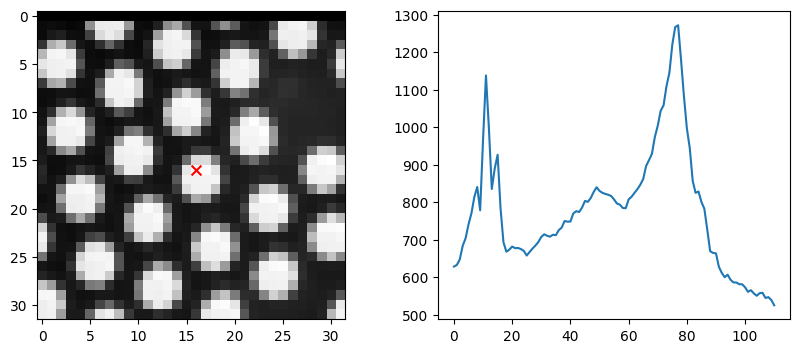

the training batch is initialized to (3, 1024)
the corresponding ground truth is thus of size (111, 3)

..............
 STARTING DKL-GP OPTIM


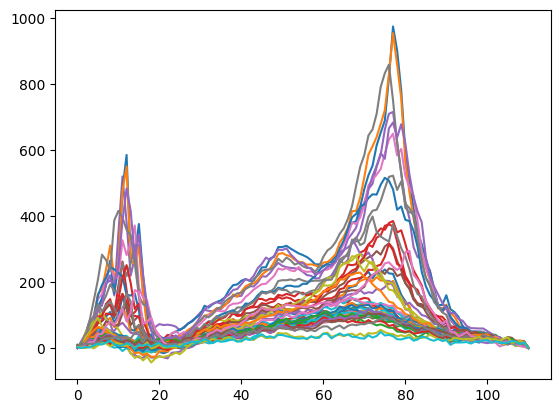

In [9]:
#scales and energy
e_ax = np.arange(0.95,1.35,1024)
imscale = 1

"""noise filtering of spectrum"""

s = np.shape(spec)
signal = np.reshape(spec,(s[0]*s[1],s[2]))
filtered = []
n = 5
for i in range(len(signal)):
  sign = pd.DataFrame(signal[i])
  filtered.append(pd.DataFrame.to_numpy(sign.rolling(n, center = False).mean()))
spac = np.reshape(np.array(filtered), (s[0], s[1], s[2]))[:,:,n//2+n%2+1:]


"""* Prepare data for ML/DL:"""

###
window_size       =  32            # select window size for geometric feature length scales
spectralavg       = 9      # average spectral channels (reduces # of channels significantly --> easier to process! usually don't need 2048 ch, a few hundred I think are sufficient)
coordinates = aoi.utils.get_coord_grid(img, step = 2, return_dict=False)
img_patches, specs, coords = aoi.utils.extract_patches_and_spectra(spac,
                                                                   img,
                                                                   coordinates=coordinates,
                                                                   window_size=window_size,
                                                                    #  band=[0, 2], # average over these slices and use as "structural data"
                                                                   avg_pool=spectralavg)
specs = specs[:,1:-1]

###
m=4
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].imshow(img_patches[m], cmap = 'gray')
ax[1].plot(specs[m]-np.min(specs)/np.max(specs-np.min(specs)))
ax[0].scatter(window_size/2, window_size/2, marker = 'x', c='r', s=50)
plt.show()

###
full_img = np.copy(img)
indices = np.copy(coords)
features = np.copy(img_patches)
targets = np.copy(specs)
scale = 1 #np.copy(imscale)
spectralavg = 1024


e_scale = np.copy(e_ax[::spectralavg])

# Match the energy scale lengths (this only occurs from the spectral averaging in previous step)
while e_scale.shape[0] > targets[0].shape[0]:
  e_scale = e_scale[:-1]

e_scale.shape, targets[0].shape

"""# Load and process"""

# Commented out IPython magic to ensure Python compatibility.
#os.cd "C:/Users/gros548/Documents/Autonomus/"
#os.mkdir DKL
#os.cd "DKL"

"""Preprocess:"""

###

norm_ = lambda x: (x - np.min(x) ) / (np.max(x) - np.min(x))
offset_ = lambda x: [x[i] - baseline_(x[i]) for i in range(len(x))]
baseline_ = lambda y: np.linspace(np.min(y[:10]), np.min(y[-10:]), len(y))
#background_ = lambda x: np.resize(np.resize(x, (st[0],16), st[-1])
sf = np.shape(features)
st = np.shape(targets)
si = np.shape(img)
features = np.reshape(features, (sf[0], np.product(sf[1:])))
targets = np.reshape(targets, (st[0], np.product(st[1:])))
image = np.reshape(img, (si[0],np.product(si[1:])))

features = norm_(offset_(features))
targets = offset_(targets)
image = norm_(image)

features = np.reshape(features, tuple(sf))
targets = np.reshape(targets, tuple(st))
image = np.reshape(image, tuple(si))

# Cheching out spectral data
#for i in range(50):
#  if np.max(targets[i]):
#    plt.plot(targets[i])
#plt.show

# process start
# %%capture

# Reduce the size of spectra via average pooling (for vector-DKL, the vector size should typically be < 200)
REDUCE = 1
y = torch.from_numpy(targets)[:, None]
y = torch.nn.functional.avg_pool1d(y, 1, 1).squeeze().numpy()

# Flatten image data
n, d1, d2 = features.shape
X = features.reshape(n, d1*d2)
X = X
# Transpose so that a spectrum length corresponds to a batch dimension in GP

y = y.T

e_reduced = np.copy(e_scale[::REDUCE])
while e_reduced.shape[0] > y.shape[0]:
  e_reduced = e_reduced[:-1]

# to use a scalar DKL-GPR, just take a single "slice" of y, e.g. y_sc = y[10:11]

"""ACTIVE LEARNING

* This is where physics is embedded into the model!
* We need to define a function that will scalarize our vector-valued acquisition function. Here, we simply take an average over a selected energy band
* However this can be anything we can imagine that can be done to the spectrum
"""

###

def scalarize_acq(obj: np.ndarray) -> np.ndarray:
    """
    Scalarize acquisition function (n_samples x vector_size)
    by averaging over a selected energy band.
    """
    band = [0, -1]
    obj = obj[:, band[0]:band[1]].mean(-1)
    return obj

#adapted sclarizer
def scalarizer2(obj: np.ndarray) -> np.ndarray:
  """
  Scalarizer acquisition function (n_samples x vector_size)
  computing Intensity variance over the spectrum
  """
  print('acquisition function', np.shape(obj))
  obj = np.sum(obj, axis = -1)
  return obj

def scalarize_wavelet(obj : np.ndarray) -> np.ndarray:
  """
  Based on the single rod resonance identification around 1µm
  """
  for index in range(len(obj)):
    coord = scipy.signal.find_peaks_cwt(obj[index, 0:100], 10, min_length = 1)#, wavelet=None, max_distances=None, gap_thresh=None, min_length=None, min_snr=1, noise_perc=10, window_size=None)
    m = np.max([obj[element] for element in coord])
    signal.append(m/np.max(targets[:,0:100]))

    obj = np.array(signal)
    return obj

"""We start with a small number (2) of randomly sampled measurements and use DKL-GPR predictions to guide the sample exploration via pre-defined acquisition functions:"""

###

# Here X_train and y_train are our measured image patches (HAADF) and spectra/peaks (EELS),
# whereas X_test and y_test are the "unknown" ones. The indices_train are grid coordinates of the measured points,
# whereas the indices_test are the grid coordinates of the remaining available points on the grid

(X_train, X_test, y_train, y_test,
 indices_train, indices_test) = train_test_split(
     X, y.T, indices, test_size=0.998, shuffle=True, random_state=20)

# The targets for the DKL-GPR must have vector_size x n_samples dimensions where vector_size is equal to spectral length
y_train = y_train.T
y_test = y_test.T

print('the training batch is initialized to',X_train.shape) # n_samples x n_features
print('the corresponding ground truth is thus of size', y_train.shape) # vector_size x n_samples
print('\n..............\n STARTING DKL-GP OPTIM')

In [ ]:
"""Run the "experiment":

* Note, if you prefer to skip ahead and not wait for this training, please go to the next section titled "**Load and reconstruct**"
"""
savedir = input('Give me a folder title to save the optim weights....')
directory = os.mkdir('/content/drive/MyDrive/shared_/'+str(savedir))

###

# Memory dump if (GPU) memory usage is high

import gc
dklgp_new = None
gc.collect()
torch.cuda.empty_cache()
with torch.no_grad():
    torch.cuda.empty_cache()

###

exploration_steps = 50  # 200 is about 7% of the points --> ~10-15 minute execution time! Note, 100 steps only takes ~3 min

xi = 0.2            # balances exploration and exploitation for EI

################################################################################
import time  # NEW LINE
time_all = []  # NEW LINE
coordinates_save = []

AF_results = []
data_dim = X_train.shape[-1]
for e in range(exploration_steps):
    print("{}/{}".format(e+1, exploration_steps))
    start_time = time.time()  # NEW LINE
    training_iter = 20 if e < 30 else 60  # originally 20, 40 ;  we do not want to "overfit" our model at the beginning

    # update GP posterior
    dklgp_new = aoi.models.dklGPR(data_dim, embedim=2, precision="double")
    dklgp_new.base_kernel = 'matern'
    #print(dklgp_new.__dict__)
    dklgp_new.fit(X_train, y_train, training_cycles=training_iter, k_type = 'rbf', nu = 2.5, hidden_dim = [2500,500,50], grid_size = 100)
    mean,var = dklgp_new.predict(X_train, batch_size = len(X_train))
    print(dklgp_new.__dict__)
    plt.plot(mean)
    plt.plot(mean-2*np.sqrt(var), "--")
    plt.plot(y_train, "k")
    plt.show()

    # Compute the acquisition function
    best_f = torch.tensor(dklgp_new.predict(X_train)[0].max())
    obj = EI(dklgp_new, X_test, best_f, xi)  #expected improvement
    # SAVE current acquisition function  EI(model: aoi.models.dklGPR, X: Union[np.ndarray, torch.Tensor],beta: Union[float, torch.Tensor] = 0.2)
    AF = save_result(indices_test, obj)
    AF_results.append(AF)

    obj = obj.T # transpose to n_samples x vector_size  for consistency

    # Scalarize the acquisition function
    obj = scalarizer2(obj)

    # Select the next point to "measure"
    next_point_idx = obj.argmax()
    next_point = indices_test[next_point_idx]
    plt.plot(y_test[:,next_point_idx])
    plt.show()
    plt.imshow(img_patches[next_point_idx])
    plt.show()
    # Do "measurement"
    measured_point = y_test[:, next_point_idx]
    # Plot current result
    plot_result(indices_test, obj, e)
    print('\n objective function ---->', np.max(obj))

    # SAVE current MODEL WEIGHTS
    state_dict = dklgp_new.gp_model.state_dict()
    torch.save(state_dict, "/content/drive/MyDrive/shared_/"+str(savedir)+"/Model_ActiveDKL {}.pt".format(e))

    emb =dklgp_new.embed(X_train)
    print(emb)
#plt.scatter(indices[:, 1], len(indices)-indices[:, 0]-1, c=np.sum(y.T, axis = 1))
#plt.scatter(indices[:, 1], len(indices)-indices[:, 0]-1, c = emb[:,0])#c=np.sum(y.T, axis = 1))
#plt.scatter(indices_train[:, 1], len(indices)-indices_train[:, 0]-1,  c='r')
    plt.scatter(emb[:, 0], emb[:,1], c = np.std(X_train,axis = -1))
    plt.show()

    # Append to the arrays of measured points
    X_train = np.append(X_train, X_test[next_point_idx][None], 0)
    X_test = np.delete(X_test, next_point_idx, 0)
    y_train = np.append(y_train, measured_point[:, None], 1)
    y_test = np.delete(y_test, next_point_idx, 1)
    indices_train = np.append(indices_train, next_point[None], 0)
    indices_test = np.delete(indices_test, next_point_idx, 0)
    time_all.append(time.time() - start_time)  # NEW LINE

    coordinates_save.append(next_point_idx)

In [14]:
"""Plot the visited points:

Overlay the explored point with a ground truth (again, we only will have a ground truth for *pre*-acquired data):
"""
# ANALYSIS PART
# %%Movies
zipped = glob.glob("C:/Users/Clotilde/OneDrive/Documents/pythonscripts/"+str(savedir)+"*.pt")

"""* Save and, if interested, download results (model weights in DKLweights zip, and acquisition function in AF_results)"""

filename = "C:/Users/Clotilde/OneDrive/Documents/pythonscripts/Acquisition_functions.npy"
np.save(filename, AF_results)

np.savez("C:/Users/Clotilde/OneDrive/Documents/pythonscripts/DKLweights_01.zip", zipped)
np.save('C:/Users/Clotilde/OneDrive/Documents/pythonscripts/coordinates_visited.npy', coordinates_save)

def silence_imageio_warning(*args, **kwargs):
    pass
imageio.core.util._precision_warn = silence_imageio_warning

directory = '~/DKL/'

AF_results = np.load(directory + 'Acquisition_functions.npy', allow_pickle = True)
print(AF_results)

structural_img = np.copy(full_img)
AF_all, AF_all_color_combo, AF_combined = Make_AF_movies_preacquired(acquisition_functions = AF_results,
                                                                     RGB = Blue,
                                                                     brightness = 2,
                                                                     measured_points_in_AF = [1,0,0],
                                                                     measured_points_in_HAADF = [1,0,0])

print(AF_all[-1])
plt.imshow(AF_all[-3])
plt.show()
sz = np.shape(full_img)
AF_all = normalize_nan(AF_all)*254
print(sz)
#AF_in = np.full(sz, None)
#AF_in[16:-15,16:-15] = AF_all[-1]
plt.imshow(full_img[16:97-16+1, 16:134-16+1], origin = 'lower')
                    #extent=(16, 134-16+1, 16, 97-16+1), cmap= mpl.colormaps['magma'], vmin=0, vmax=1)
#plt.imshow(AF_all[-1], extent=(16, 134-16+1, 16, 97-16+1), origin = 'lower', vmin=0, vmax=1)

plt.show()

structural_img = np.copy(full_img)
AF_all, AF_all_color_combo, AF_combined = Make_AF_movies_preacquired(acquisition_functions = AF_results,
                                                                     RGB = Blue,
                                                                     brightness = 2,
                                                                     measured_points_in_AF = [1,0,0],
                                                                     measured_points_in_HAADF = [1,0,0])

plt.imshow(AF_all[8])
plt.show()
sz = np.shape(full_img)
AF_all = normalize_nan(AF_all)*254
print(sz)
#AF_in = np.full(sz, None)
#AF_in[16:-15,16:-15] = AF_all[-1]
plt.imshow(full_img[16:97-16+1, 16:134-16+1], origin = 'lower')
                    #extent=(16, 134-16+1, 16, 97-16+1), cmap= mpl.colormaps['magma'], vmin=0, vmax=1)
#plt.imshow(AF_all[-1], extent=(16, 134-16+1, 16, 97-16+1), origin = 'lower', vmin=0, vmax=1)

plt.show()

size_increase = 6

HAADF_mov = create_point_search_mov_preacquired(full_img, indices_train, AF_combined, size = structural_img.shape, point_radius = 1, point_color = [0,0,0], offset = 0)
AF_resized = resize(AF_all_color_combo, HAADF_mov.shape)
Movie_combined = np.concatenate((AF_resized, HAADF_mov), axis = 2)

s1,s2,s3,s4 =  Movie_combined.shape
Movie_combined_upscaled = resize(Movie_combined, (s1,s2*size_increase,s3*size_increase,s4))

Mov_name = "AcquisitionFunction_mov1.mp4"

imageio.mimwrite(Mov_name, Movie_combined_upscaled, fps = 10)
Video(Mov_name, embed = True)

"""Rather successful in finding intended behavior (defined by the "scalarize_acq" function)

* Zip all the weights, then download
"""


"""#### (Checkpoint) Load and reconstruct

### Reconstructions/Predictions

* Load and evaluate model performance at specific fractions of measured data points
"""

weights_files = []
weights_files = sorted(glob.glob('*.pt'))
len(weights_files)

"""* Use model at this step.... (note, later cells use a function to accomplish the following two cells)"""

step = 39  # model step from which to load weights

#####################################
### do not change below parameters ###
#####################################
print(np.shape(weights_files))
weights = weights_files[step]
device = 'cpu'            # constant
dtype = torch.float64     # constant

dklgp_trained =  aoi.models.dklGPR(data_dim, embedim=2, precision="double")
dklgp_trained.compile_trainer(X, y) # extra step.

# Load trained weights
state_dict = torch.load(weights)
dklgp_trained.gp_model.load_state_dict(state_dict)

mean,var = dklgp_trained.predict(X, batch_size = len(X))
structural_img = full_img.copy()
s1, s2 = structural_img.shape[0] - window_size+1, structural_img.shape[1] - window_size+1
s3 = y.shape[0]

dkl_prediction = np.full((s1*s2,s3), np.nan)
dkl_uncertainty = np.full((s1*s2,s3), np.nan)
#dy= 2*np.sqrt(var)
#dy = dy.T
for ii in range(s3):
  dkl_prediction[ii] = mean.T[ii, :]
  dkl_uncertainty[ii] = var.T[ii, :]
  dy = 2*np.sqrt(dkl_uncertainty[ii])
  plt.plot(np.arange(s3),dkl_prediction[ii])
  plt.plot(np.arange(s3), targets[ii], '--')
  #plt.fill_between(np.arange(s3), dkl_prediction[ii]-dy[ii], dkl_prediction[ii]+dy[ii], alpha=0.2)
  plt.fill_between(np.arange(s3), dkl_prediction[ii]-dy, dkl_prediction[ii]+dy, alpha=0.2)
  plt.title('uncertainty/prediction/gt step Nr'+ str(ii))
  plt.show()


dkl_prediction = dkl_prediction.reshape((s1,s2,s3))
dkl_uncertainty = dkl_uncertainty.reshape((s1,s2,s3))
plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(1,2)
ax1,ax2 = plt.subplot(gs[0]), plt.subplot(gs[1])

k1,k2 = 0, -1
ax1.imshow(np.mean(dkl_prediction[:,:,k1:k2],axis = 2), origin = 'lower')
ax2.imshow(np.mean(dkl_uncertainty[:,:,k1:k2], axis = 2), origin = 'lower')

ax1.set_title('DKL prediction step {}: spectral average'.format(step))
ax2.set_title('DKL uncertainty step {}: spectral average'.format(step))

ax1.axis('off'), ax2.axis('off');
#plt.show()

print(np.shape(dkl_prediction[:,:,k1:k2]))
plt.imshow(np.mean(dkl_prediction[:,:,k1:k2],axis = 2), origin = 'lower')
plt.show()
plt.imshow(np.mean(dkl_uncertainty[:,:,k1:k2], axis = 2), origin = 'lower')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Clotilde/OneDrive/Documents/pythonscripts/Acquisition_functions.npy'